In [130]:
from skyfield.api import load, wgs84
import matplotlib.pyplot as plt
import numpy as np
import json
import pandas as pd

In [131]:
# (Lab 2 constants – new)
SATELLITE_NAME = "SENTINEL-1A"

GROUND_STATION_NAME = "Aarhus, Denmark"
GROUND_LAT = 56.1629
GROUND_LON = 10.2039
GROUND_ELEV_M = 0

PASS_DISTANCE_KM = 1000
TIME_STEP_MIN = 5

In [132]:
# (Lab 1 reuse)
tle_url = "https://celestrak.org/NORAD/elements/gp.php?GROUP=active&FORMAT=tle"
satellites = load.tle_file(tle_url)

print("Loaded satellites:", len(satellites))

Loaded satellites: 14304


In [133]:
# (Lab 1 reuse)
by_name = {sat.name: sat for sat in satellites}
sentinel = by_name[SATELLITE_NAME]

print("Tracking satellite:", sentinel.name)

Tracking satellite: SENTINEL-1A


In [134]:
# (Lab 1 reuse)
ts = load.timescale()

# (New in Lab 2: full-day time window)
minutes = range(0, 24 * 60, TIME_STEP_MIN)
times = ts.utc(2026, 1, 1, 0, minutes)

print("Number of time steps:", len(times))

Number of time steps: 288


In [135]:
# (Lab 1 reuse)
positions = sentinel.at(times)

In [136]:
# (Lab 1 reuse)
ground_station = wgs84.latlon(
    GROUND_LAT,
    GROUND_LON,
    elevation_m=GROUND_ELEV_M
)

In [137]:
# (New in Lab 2)
difference = (sentinel - ground_station).at(times)
distances_km = difference.distance().km

print("Min distance (km):", np.min(distances_km))
print("Max distance (km):", np.max(distances_km))

Min distance (km): 811.9064584593092
Max distance (km): 13428.96400508595


In [138]:
# (New in Lab 2)
pass_indices = np.where(distances_km < PASS_DISTANCE_KM)[0]

passes = []
current_pass = [pass_indices[0]]

for idx in pass_indices[1:]:
    if idx == current_pass[-1] + 1:
        # Still in the same pass
        current_pass.append(idx)
    else:
        # Pass ended, start a new one
        passes.append(current_pass)
        current_pass = [idx]
# Add the last pass
passes.append(current_pass)

print("Number of passes found:", len(passes))

Number of passes found: 2


In [139]:
passes[0]

[81]

In [140]:
# New in Lab 2
pass_info = []

# For each pass:
for p in passes:
    print(p)
    # Start and end indices of the pass
    start_idx = p[0]
    end_idx = p[-1]

    # Corresponding times
    start_time = times[start_idx]
    end_time = times[end_idx]

    # Find index of minimum distance within this pass
    min_idx = p[np.argmin(distances_km[p])]

    # Minimum distance and its time
    min_distance = distances_km[min_idx]
    min_time = times[min_idx]

    pass_info.append({
        "start": start_time.utc_strftime('%Y-%m-%d %H:%M:%S'),
        "end": end_time.utc_strftime('%Y-%m-%d %H:%M:%S'),
        "min_distance": min_distance,
        "min_time": min_time.utc_strftime('%Y-%m-%d %H:%M:%S')
    })

[81]
[196]


In [141]:
# New in Lab 2
# Rank passes by minimum distance (closest first)
ranked_passes = sorted(
    pass_info,
    key=lambda p: p["min_distance"]
)
# Checkpoint: print top 3 passes
for i, p in enumerate(ranked_passes[:3], start=1):
    print(
        f"Rank {i}: {p['min_distance']:.1f} km at {p['min_time']}"
    )

Rank 1: 811.9 km at 2026-01-01 16:20:00
Rank 2: 985.5 km at 2026-01-01 06:45:00


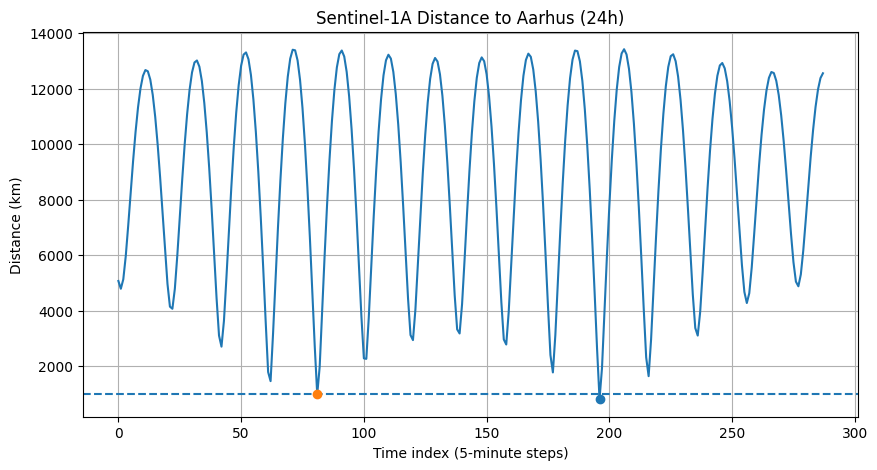

In [142]:
# (Partially reused from Lab 1)
# New in Lab 2, but plotting style reused from Lab 1
plt.figure(figsize=(10, 5))

# TODO: Plot distance vs time index
plt.plot(distances_km, label="Distance to Aarhus")

#Draw pass threshold line
plt.axhline(
    PASS_DISTANCE_KM,
    linestyle="--",
    label="Pass threshold"
)

# TODO: Mark closest approaches for each ranked pass
for p in ranked_passes:
    min_idx = np.where(distances_km == p["min_distance"])[0][0]
    plt.scatter(
        min_idx,
        p["min_distance"],
        zorder=5
    )

plt.title("Sentinel-1A Distance to Aarhus (24h)")
plt.xlabel("Time index (5-minute steps)")
plt.ylabel("Distance (km)")
plt.grid(True)
plt.show()

In [143]:
for p in ranked_passes:
    if p["min_distance"] < 600 and p["duration_minutes"] >= 8: # Changed from "min_distance_km"
        p["decision"] = "SEND_COMMAND"
    elif p["min_distance"] < PASS_DISTANCE_KM: # Changed from "min_distance_km"
        p["decision"] = "DOWNLINK_TELEMETRY"
    else:
        p["decision"] = "IGNORE"

In [144]:
ranked_passes

[{'start': '2026-01-01 16:20:00',
  'end': '2026-01-01 16:20:00',
  'min_distance': 811.9064584593092,
  'min_time': '2026-01-01 16:20:00',
  'decision': 'DOWNLINK_TELEMETRY'},
 {'start': '2026-01-01 06:45:00',
  'end': '2026-01-01 06:45:00',
  'min_distance': 985.465740028434,
  'min_time': '2026-01-01 06:45:00',
  'decision': 'DOWNLINK_TELEMETRY'}]

In [145]:
output = {
    "satellite": "Sentinel-1A",
    "ground_station": "Aarhus, Denmark",
    "pass_count": len(ranked_passes),
    "passes": ranked_passes
}

print(json.dumps(output, indent=2))

{
  "satellite": "Sentinel-1A",
  "ground_station": "Aarhus, Denmark",
  "pass_count": 2,
  "passes": [
    {
      "start": "2026-01-01 16:20:00",
      "end": "2026-01-01 16:20:00",
      "min_distance": 811.9064584593092,
      "min_time": "2026-01-01 16:20:00",
      "decision": "DOWNLINK_TELEMETRY"
    },
    {
      "start": "2026-01-01 06:45:00",
      "end": "2026-01-01 06:45:00",
      "min_distance": 985.465740028434,
      "min_time": "2026-01-01 06:45:00",
      "decision": "DOWNLINK_TELEMETRY"
    }
  ]
}
